In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train — death rate: {y_train.mean():.3f}')
print(f'y_test  — death rate: {y_test.mean():.3f}')


X_train : (73370, 263)
X_test  : (18343, 263)
y_train — death rate: 0.086
y_test  — death rate: 0.086


In [2]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(model, X, y, dataset_name='Test', threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    print(f'=== {dataset_name} Results (threshold={threshold}) ===')
    print(f'AUROC     : {roc_auc_score(y, y_proba):.4f}')
    print(f'AUPRC     : {average_precision_score(y, y_proba):.4f}')
    print(f'Accuracy  : {accuracy_score(y, y_pred):.4f}')
    print(f'Precision : {precision_score(y, y_pred):.4f}')
    print(f'Recall    : {recall_score(y, y_pred):.4f}')
    print(f'F1        : {f1_score(y, y_pred):.4f}')

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Died'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {dataset_name} (threshold={threshold})')
    plt.tight_layout()
    plt.show()


Baseline — Logistic Regression
=== Test Results (threshold=0.5) ===
AUROC     : 0.8847
AUPRC     : 0.5092
Accuracy  : 0.9258
Precision : 0.6632
Recall    : 0.2849
F1        : 0.3986


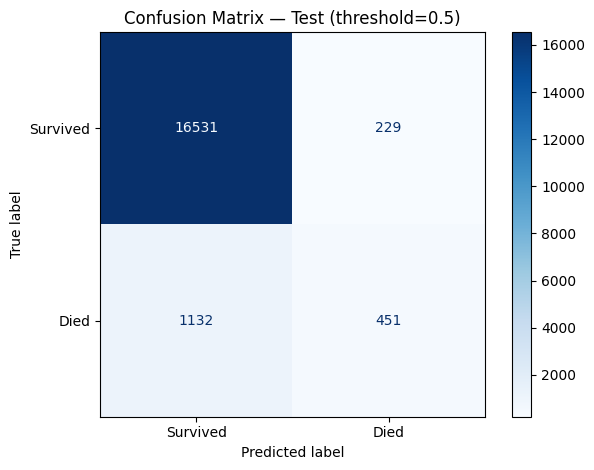

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

baseline.fit(X_train, y_train)

print('Baseline — Logistic Regression')
evaluate_model(baseline, X_test, y_test, dataset_name='Test')


Model — Decision Tree
=== Decision Tree — Test Results (threshold=0.5) ===
AUROC     : 0.8227
AUPRC     : 0.4144
Accuracy  : 0.9207
Precision : 0.5875
Recall    : 0.2735
F1        : 0.3733


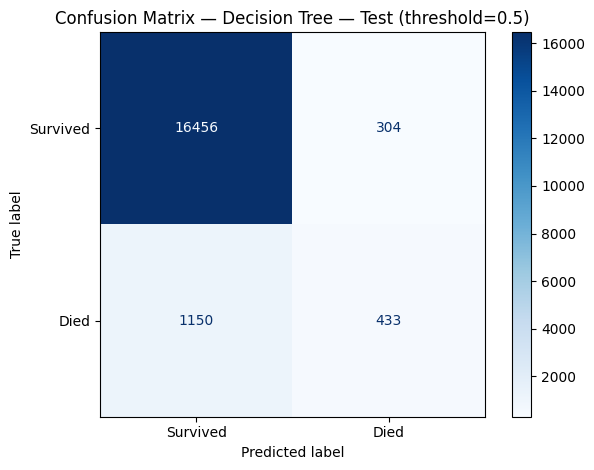

In [4]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

dt.fit(X_train, y_train)

print('Model — Decision Tree')
evaluate_model(dt, X_test, y_test, dataset_name='Decision Tree — Test')


Model — Random Forest

=== Test Results (threshold=0.5) ===
AUROC     : 0.8901
AUPRC     : 0.5526
Accuracy  : 0.9290
Precision : 0.8431
Recall    : 0.2173
F1        : 0.3456


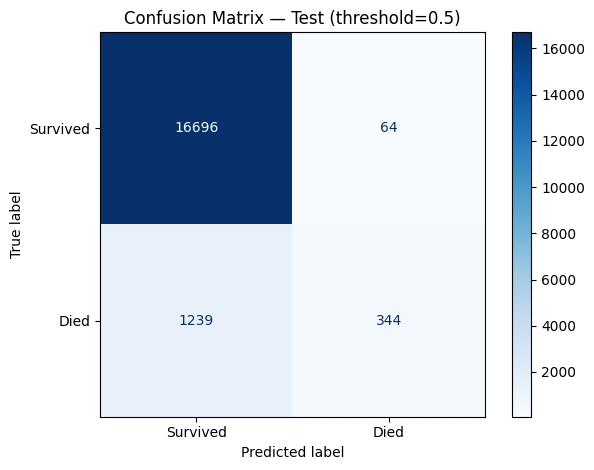

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('Model — Random Forest\n')
evaluate_model(rf, X_test, y_test, dataset_name='Test')


[0]	validation_0-aucpr:0.37998
[50]	validation_0-aucpr:0.54222
[100]	validation_0-aucpr:0.56352
[150]	validation_0-aucpr:0.57268
[200]	validation_0-aucpr:0.57561
[239]	validation_0-aucpr:0.57664

Model — XGBoost

=== XGBoost — Test Results (threshold=0.5) ===
AUROC     : 0.9044
AUPRC     : 0.5835
Accuracy  : 0.9328
Precision : 0.7461
Recall    : 0.3361
F1        : 0.4634


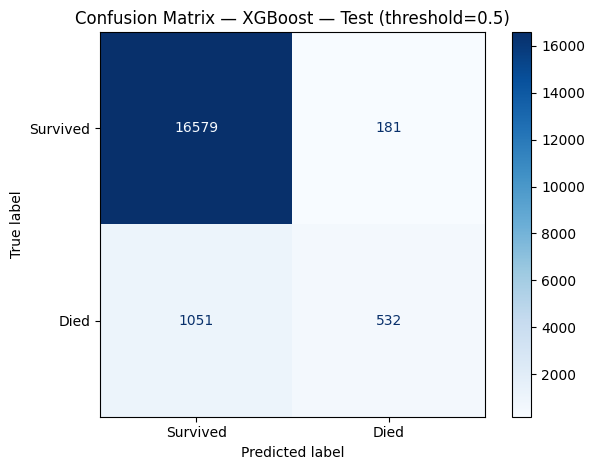

In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    verbosity=0,
    n_jobs=-1
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print('\nModel — XGBoost\n')
evaluate_model(xgb, X_test, y_test, dataset_name='XGBoost — Test')

Model — LightGBM

=== LightGBM — Test Results (threshold=0.5) ===
AUROC     : 0.9034
AUPRC     : 0.5810
Accuracy  : 0.9329
Precision : 0.7441
Recall    : 0.3399
F1        : 0.4666


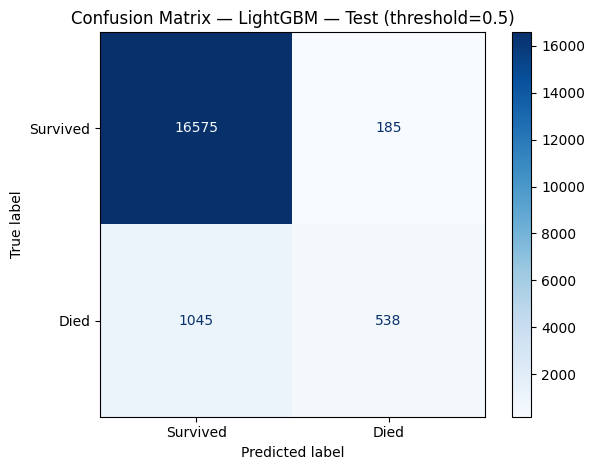

In [7]:
from lightgbm import LGBMClassifier, early_stopping

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[early_stopping(20, verbose=False)]
)

print('Model — LightGBM\n')
evaluate_model(lgbm, X_test, y_test, dataset_name='LightGBM — Test')

In [8]:
def compare_models(models_dict, X, y, threshold=0.5):
    results = []

    for name, model in models_dict.items():
        y_proba = model.predict_proba(X)[:, 1]
        y_pred  = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        results.append({
            'Model'     : name,
            'AUROC'     : round(roc_auc_score(y, y_proba), 4),
            'AUPRC'     : round(average_precision_score(y, y_proba), 4),
            'Accuracy'  : round(accuracy_score(y, y_pred), 4),
            'Precision' : round(precision_score(y, y_pred, zero_division=0), 4),
            'Recall'    : round(recall_score(y, y_pred, zero_division=0), 4),
            'F1'        : round(f1_score(y, y_pred, zero_division=0), 4),
            'TN'        : tn,
            'FP'        : fp,
            'FN'        : fn,
            'TP'        : tp,
        })

    return pd.DataFrame(results).set_index('Model')
models = {
    'Logistic Regression' : baseline,
    'Decision Tree'       : dt,
    'Random Forest'       : rf,
    'XGBoost'             : xgb,
    'LightGBM'            : lgbm,
}

baseline_results = compare_models(models, X_test, y_test)
baseline_results

,AUROC,AUPRC,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Model,,,,,,,,,,
Logistic Regression,0.8847,0.5092,0.9258,0.6632,0.2849,0.3986,16531,229,1132,451
Decision Tree,0.8227,0.4144,0.9207,0.5875,0.2735,0.3733,16456,304,1150,433
Random Forest,0.8901,0.5526,0.9290,0.8431,0.2173,0.3456,16696,64,1239,344
XGBoost,0.9044,0.5835,0.9328,0.7461,0.3361,0.4634,16579,181,1051,532
LightGBM,0.9034,0.5810,0.9329,0.7441,0.3399,0.4666,16575,185,1045,538


In [9]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


scale_pos_weight: 10.59


Model — XGBoost + scale_pos_weight

=== XGBoost Balanced — Test Results (threshold=0.5) ===
AUROC     : 0.8980
AUPRC     : 0.5631
Accuracy  : 0.8647
Precision : 0.3573
Recall    : 0.7100
F1        : 0.4754


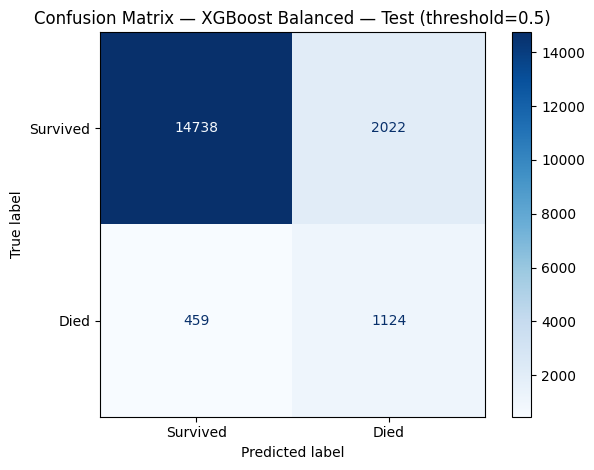

In [10]:
xgb_balanced = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    verbosity=0,
    n_jobs=-1
)

xgb_balanced.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('Model — XGBoost + scale_pos_weight\n')
evaluate_model(xgb_balanced, X_test, y_test, dataset_name='XGBoost Balanced — Test')


Model — LightGBM + class_weight balanced

=== LightGBM Class Weighted — Test Results (threshold=0.5) ===
AUROC     : 0.9015
AUPRC     : 0.5699
Accuracy  : 0.8421
Precision : 0.3258
Recall    : 0.7757
F1        : 0.4589


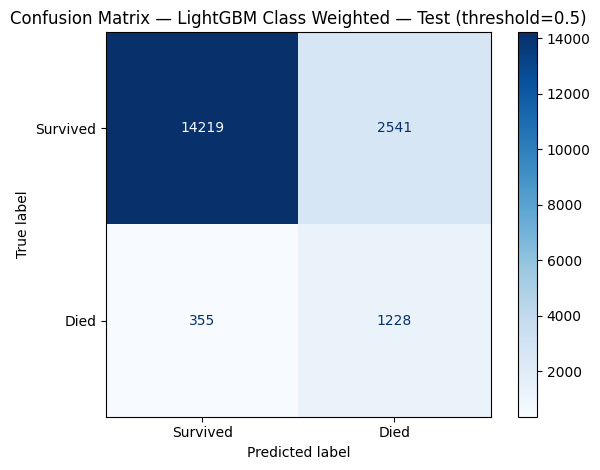

In [11]:
lgbm_class_weighted = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_class_weighted.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[early_stopping(20, verbose=False)]
)

print('Model — LightGBM + class_weight balanced\n')
evaluate_model(
    lgbm_class_weighted,
    X_test,
    y_test,
    dataset_name='LightGBM Class Weighted — Test'
)

In [12]:
boosting_models = {
    'XGBoost'           : xgb,
    'XGBoost Balanced'  : xgb_balanced,
    'LightGBM'          : lgbm,
    'LightGBM Balanced' : lgbm_class_weighted,
}

boosting_results = compare_models(boosting_models, X_test, y_test)
boosting_results

,AUROC,AUPRC,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Model,,,,,,,,,,
XGBoost,0.9044,0.5835,0.9328,0.7461,0.3361,0.4634,16579,181,1051,532
XGBoost Balanced,0.8980,0.5631,0.8647,0.3573,0.7100,0.4754,14738,2022,459,1124
LightGBM,0.9034,0.5810,0.9329,0.7441,0.3399,0.4666,16575,185,1045,538
LightGBM Balanced,0.9015,0.5699,0.8421,0.3258,0.7757,0.4589,14219,2541,355,1228


In [13]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb_clean(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'early_stopping_rounds': 30
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_fold_train = X_tr.iloc[train_idx]
        X_fold_val   = X_tr.iloc[val_idx]
        y_fold_train = y_tr.iloc[train_idx]
        y_fold_val   = y_tr.iloc[val_idx]

        fold_scale_pos_weight = (y_fold_train == 0).sum() / (y_fold_train == 1).sum()

        model = XGBClassifier(
            **params,
            scale_pos_weight=fold_scale_pos_weight
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )

        y_val_proba = model.predict_proba(X_fold_val)[:, 1]
        scores.append(average_precision_score(y_fold_val, y_val_proba))

    return np.mean(scores)


study_xgb_clean = optuna.create_study(direction='maximize')
study_xgb_clean.optimize(objective_xgb_clean, n_trials=50, show_progress_bar=True)

print(f'Best XGBoost CV AUPRC: {study_xgb_clean.best_value:.4f}')
print('Best params:')
study_xgb_clean.best_params

  0%|          | 0/50 [00:00<?, ?it/s]

Best XGBoost CV AUPRC: 0.5445
Best params:


{'n_estimators': 972,
 'learning_rate': 0.021850565363548093,
 'max_depth': 8,
 'min_child_weight': 18.881327493089618,
 'subsample': 0.9056285593246436,
 'colsample_bytree': 0.8416735525101696,
 'gamma': 0.16502787514563477,
 'reg_alpha': 0.002037387122467638,
 'reg_lambda': 5.288034263482317e-05}

In [14]:
best_xgb_params = study_xgb_clean.best_params

scale_pos_weight_tr = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_tuned_clean = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=scale_pos_weight_tr,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_tuned_clean.fit(X_tr, y_tr)

print('Clean tuned XGBoost trained.')

Clean tuned XGBoost trained.


In [15]:
import optuna
import numpy as np

from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgbm_clean(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'binary',
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_fold_train = X_tr.iloc[train_idx]
        X_fold_val   = X_tr.iloc[val_idx]
        y_fold_train = y_tr.iloc[train_idx]
        y_fold_val   = y_tr.iloc[val_idx]

        model = LGBMClassifier(**params)

        model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            eval_metric='average_precision',
            callbacks=[early_stopping(30, verbose=False)]
        )

        y_val_proba = model.predict_proba(X_fold_val)[:, 1]
        scores.append(average_precision_score(y_fold_val, y_val_proba))

    return np.mean(scores)


study_lgbm_clean = optuna.create_study(direction='maximize')
study_lgbm_clean.optimize(objective_lgbm_clean, n_trials=50, show_progress_bar=True)

print(f'Best LightGBM CV AUPRC: {study_lgbm_clean.best_value:.4f}')
print('Best params:')
study_lgbm_clean.best_params

  0%|          | 0/50 [00:00<?, ?it/s]

Best LightGBM CV AUPRC: 0.5469
Best params:


{'n_estimators': 1192,
 'learning_rate': 0.022578000842241056,
 'max_depth': 10,
 'num_leaves': 90,
 'min_child_samples': 100,
 'subsample': 0.769821890932151,
 'colsample_bytree': 0.6295214331226718,
 'reg_alpha': 3.7243837057375626e-08,
 'reg_lambda': 9.70411137620181}

In [16]:
best_lgbm_params = study_lgbm_clean.best_params

lgbm_tuned_clean = LGBMClassifier(
    **best_lgbm_params,
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_tuned_clean.fit(X_tr, y_tr)

print('Clean tuned LightGBM trained.')

Clean tuned LightGBM trained.


In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

def threshold_sweep(model, X, y, thresholds):
    y_proba = model.predict_proba(X)[:, 1]
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        rows.append({
            'threshold': round(threshold, 2),
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred, zero_division=0),
            'Recall': recall_score(y, y_pred, zero_division=0),
            'F1': f1_score(y, y_pred, zero_division=0),
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp
        })

    return pd.DataFrame(rows)


thresholds = np.arange(0.10, 0.91, 0.05)

xgb_threshold_results = threshold_sweep(
    xgb_tuned_clean,
    X_val,
    y_val,
    thresholds
)

lgbm_threshold_results = threshold_sweep(
    lgbm_tuned_clean,
    X_val,
    y_val,
    thresholds
)


print('=== XGBoost Tuned — Best Thresholds by F1 ===')
display(
    xgb_threshold_results
    .sort_values('F1', ascending=False)
    .head(10)
)

print('=== LightGBM Tuned — Best Thresholds by F1 ===')
display(
    lgbm_threshold_results
    .sort_values('F1', ascending=False)
    .head(10)
)


best_xgb_threshold = (
    xgb_threshold_results
    .sort_values('F1', ascending=False)
    .iloc[0]['threshold']
)

best_lgbm_threshold = (
    lgbm_threshold_results
    .sort_values('F1', ascending=False)
    .iloc[0]['threshold']
)

print(f'Best XGBoost threshold by F1 : {best_xgb_threshold}')
print(f'Best LightGBM threshold by F1: {best_lgbm_threshold}')

=== XGBoost Tuned — Best Thresholds by F1 ===


,threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
10,0.60,0.917541,0.521053,0.547393,0.533898,12771,637,573,693
9,0.55,0.911203,0.487901,0.589258,0.533810,12625,783,520,746
11,0.65,0.922720,0.557592,0.504739,0.529851,12901,507,627,639
8,0.50,0.901731,0.450226,0.628752,0.524720,12436,972,470,796
12,0.70,0.927968,0.609424,0.459716,0.524088,13035,373,684,582
7,0.45,0.891372,0.418972,0.669826,0.515502,12232,1176,418,848
13,0.75,0.929740,0.647799,0.406793,0.499757,13128,280,751,515
6,0.40,0.877130,0.384813,0.708531,0.498749,11974,1434,369,897
5,0.35,0.860161,0.353795,0.751185,0.481032,11671,1737,315,951
14,0.80,0.931580,0.705329,0.355450,0.472689,13220,188,816,450


=== LightGBM Tuned — Best Thresholds by F1 ===


,threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
10,0.60,0.917746,0.521901,0.555292,0.538079,12764,644,563,703
11,0.65,0.922448,0.554146,0.517378,0.535131,12881,527,611,655
9,0.55,0.910999,0.487013,0.592417,0.534569,12618,790,516,750
8,0.50,0.903298,0.456950,0.641390,0.533684,12443,965,454,812
12,0.70,0.927150,0.599797,0.467615,0.525522,13013,395,674,592
7,0.45,0.891918,0.420792,0.671406,0.517346,12238,1170,416,850
13,0.75,0.929467,0.641026,0.414692,0.503597,13114,294,741,525
6,0.40,0.878833,0.388210,0.702212,0.500000,12007,1401,377,889
5,0.35,0.864250,0.360169,0.738547,0.484205,11747,1661,331,935
14,0.80,0.931784,0.702290,0.363349,0.478917,13213,195,806,460


Best XGBoost threshold by F1 : 0.6
Best LightGBM threshold by F1: 0.6


Final Test — XGBoost Tuned Clean
=== XGBoost Tuned Clean — Test Results (threshold=0.6) ===
AUROC     : 0.9011
AUPRC     : 0.5782
Accuracy  : 0.9158
Precision : 0.5115
Recall    : 0.5338
F1        : 0.5224


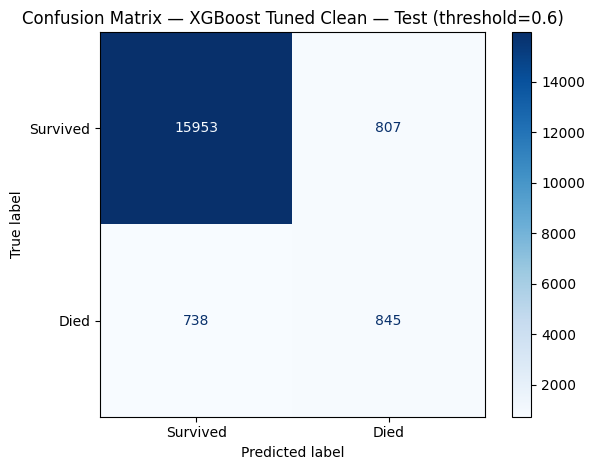

Final Test — LightGBM Tuned Clean
=== LightGBM Tuned Clean — Test Results (threshold=0.6) ===
AUROC     : 0.9019
AUPRC     : 0.5824
Accuracy  : 0.9164
Precision : 0.5144
Recall    : 0.5534
F1        : 0.5332


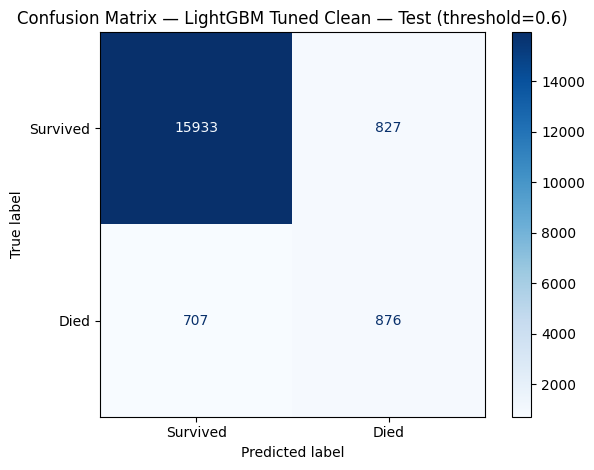

In [18]:
print('Final Test — XGBoost Tuned Clean')
evaluate_model(
    xgb_tuned_clean,
    X_test,
    y_test,
    dataset_name='XGBoost Tuned Clean — Test',
    threshold=best_xgb_threshold
)

print('Final Test — LightGBM Tuned Clean')
evaluate_model(
    lgbm_tuned_clean,
    X_test,
    y_test,
    dataset_name='LightGBM Tuned Clean — Test',
    threshold=best_lgbm_threshold
)

Final Test — LightGBM Tuned Clean, threshold=0.50
=== LightGBM Tuned Clean — Test Results (threshold=0.5) ===
AUROC     : 0.9019
AUPRC     : 0.5824
Accuracy  : 0.9013
Precision : 0.4486
Recall    : 0.6286
F1        : 0.5235


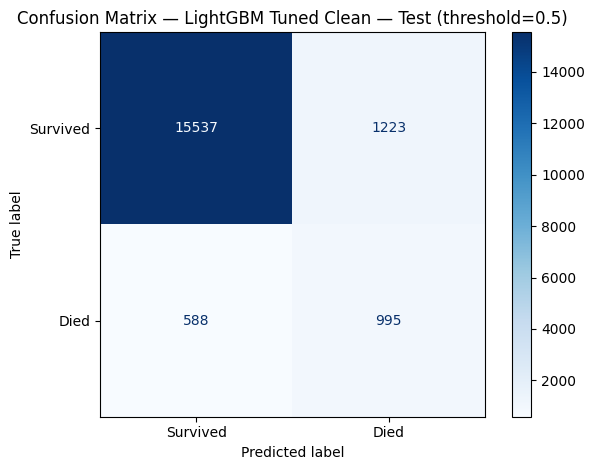

In [19]:
print('Final Test — LightGBM Tuned Clean, threshold=0.50')
evaluate_model(
    lgbm_tuned_clean,
    X_test,
    y_test,
    dataset_name='LightGBM Tuned Clean — Test',
    threshold=0.50
)

Final Test — Selected Model: LightGBM Tuned Clean, threshold=0.50
=== Selected LightGBM — Test Results (threshold=0.5) ===
AUROC     : 0.9019
AUPRC     : 0.5824
Accuracy  : 0.9013
Precision : 0.4486
Recall    : 0.6286
F1        : 0.5235


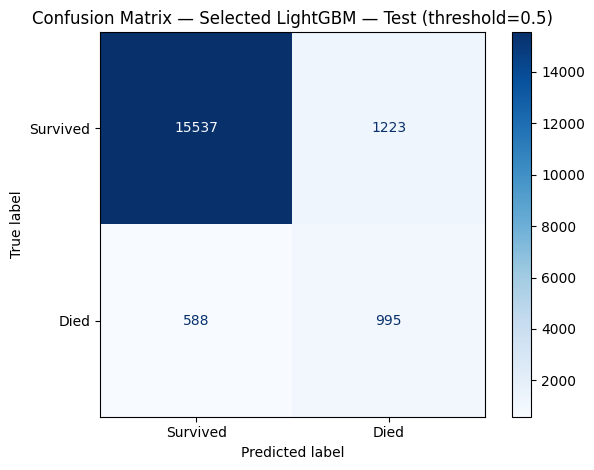

In [20]:
print('Final Test — Selected Model: LightGBM Tuned Clean, threshold=0.50')

evaluate_model(
    lgbm_tuned_clean,
    X_test,
    y_test,
    dataset_name='Selected LightGBM — Test',
    threshold=0.50
)

In [21]:
final_models = {
    'Logistic Regression': (baseline, 0.50),
    'Decision Tree': (dt, 0.50),
    'Random Forest': (rf, 0.50),
    'XGBoost': (xgb, 0.50),
    'LightGBM': (lgbm, 0.50),
    'XGBoost Balanced': (xgb_balanced, 0.50),
    'LightGBM Balanced': (lgbm_class_weighted, 0.50),
    'XGBoost Tuned Clean': (xgb_tuned_clean, 0.60),
    'LightGBM Tuned Clean': (lgbm_tuned_clean, 0.60),
    'Selected LightGBM': (lgbm_tuned_clean, 0.50),
}

def final_model_comparison(models_dict, X, y):
    rows = []

    for name, (model, threshold) in models_dict.items():
        y_proba = model.predict_proba(X)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        rows.append({
            'Model': name,
            'Threshold': threshold,
            'AUROC': round(roc_auc_score(y, y_proba), 4),
            'AUPRC': round(average_precision_score(y, y_proba), 4),
            'Accuracy': round(accuracy_score(y, y_pred), 4),
            'Precision': round(precision_score(y, y_pred, zero_division=0), 4),
            'Recall': round(recall_score(y, y_pred, zero_division=0), 4),
            'F1': round(f1_score(y, y_pred, zero_division=0), 4),
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp
        })

    return pd.DataFrame(rows).sort_values(
        by=['AUPRC', 'Recall', 'F1'],
        ascending=False
    )

final_results = final_model_comparison(final_models, X_test, y_test)
final_results

,Model,Threshold,AUROC,AUPRC,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
3,XGBoost,0.5,0.9044,0.5835,0.9328,0.7461,0.3361,0.4634,16579,181,1051,532
9,Selected LightGBM,0.5,0.9019,0.5824,0.9013,0.4486,0.6286,0.5235,15537,1223,588,995
8,LightGBM Tuned Clean,0.6,0.9019,0.5824,0.9164,0.5144,0.5534,0.5332,15933,827,707,876
4,LightGBM,0.5,0.9034,0.5810,0.9329,0.7441,0.3399,0.4666,16575,185,1045,538
7,XGBoost Tuned Clean,0.6,0.9011,0.5782,0.9158,0.5115,0.5338,0.5224,15953,807,738,845
6,LightGBM Balanced,0.5,0.9015,0.5699,0.8421,0.3258,0.7757,0.4589,14219,2541,355,1228
5,XGBoost Balanced,0.5,0.8980,0.5631,0.8647,0.3573,0.7100,0.4754,14738,2022,459,1124
2,Random Forest,0.5,0.8901,0.5526,0.9290,0.8431,0.2173,0.3456,16696,64,1239,344
0,Logistic Regression,0.5,0.8847,0.5092,0.9258,0.6632,0.2849,0.3986,16531,229,1132,451
1,Decision Tree,0.5,0.8227,0.4144,0.9207,0.5875,0.2735,0.3733,16456,304,1150,433


In [23]:
import joblib
import os
import json

os.makedirs('../models', exist_ok=True)

final_threshold = 0.50

joblib.dump(lgbm_tuned_clean, '../models/lgbm_tuned_clean.pkl')

with open('../models/lgbm_tuned_clean_threshold.json', 'w') as f:
    json.dump({'threshold': final_threshold}, f, indent=4)

print('Model saved.')
print(f'Selected threshold: {final_threshold}')

Model saved.
Selected threshold: 0.5
